In [3]:

import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Deep learning
import tensorflow as tf

import random


In [4]:
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


TensorFlow version: 2.20.0
NumPy version: 1.26.4
GPU available: []


In [6]:

CSV_PATH = "dataset/HAM10000/HAM10000_metadata.csv"

IMG_DIR_1 = "dataset/HAM10000/HAM10000_images_part_1"
IMG_DIR_2 = "dataset/HAM10000/HAM10000_images_part_2"

print("CSV exists:", os.path.exists(CSV_PATH))
print("Image dir 1 exists:", os.path.exists(IMG_DIR_1))
print("Image dir 2 exists:", os.path.exists(IMG_DIR_2))



CSV exists: True
Image dir 1 exists: True
Image dir 2 exists: True


In [7]:
df = pd.read_csv(CSV_PATH)

print("Total samples:", len(df))
df.head()


Total samples: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   dataset       10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


In [9]:
df.isnull().sum()


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dataset          0
dtype: int64

In [10]:
# Diagnosis to numeric label mapping
label_map = {
    'akiec': 0,   # Actinic keratoses
    'bcc': 1,     # Basal cell carcinoma
    'bkl': 2,     # Benign keratosis
    'df': 3,      # Dermatofibroma
    'mel': 4,     # Melanoma
    'nv': 5,      # Nevus
    'vasc': 6     # Vascular lesion
}

df['label'] = df['dx'].map(label_map)

df[['dx', 'label']].head()


,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [11]:
def get_image_path(image_id):
    path1 = os.path.join(IMG_DIR_1, image_id + ".jpg")
    path2 = os.path.join(IMG_DIR_2, image_id + ".jpg")
    
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df['filepath'] = df['image_id'].apply(get_image_path)


In [12]:
missing_files = df['filepath'].isnull().sum()
print("Missing image files:", missing_files)


Missing image files: 0


(-0.5, 599.5, 449.5, -0.5)

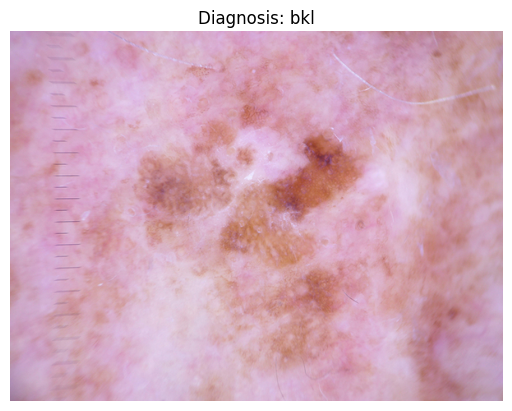

In [13]:
sample_path = df['filepath'].iloc[0]
img = plt.imread(sample_path)

plt.imshow(img)
plt.title(f"Diagnosis: {df['dx'].iloc[0]}")
plt.axis("off")


In [14]:
class_counts = df['dx'].value_counts()
class_counts
#shows highly imbalance with nevus dominating

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

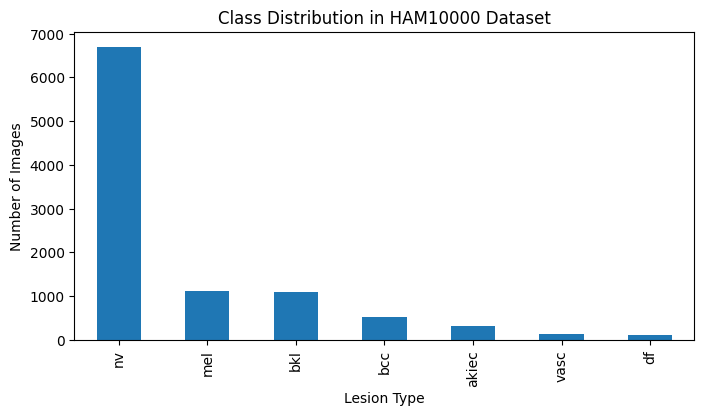

In [15]:
plt.figure(figsize=(8,4))
class_counts.plot(kind='bar')
plt.title("Class Distribution in HAM10000 Dataset")
plt.xlabel("Lesion Type")
plt.ylabel("Number of Images")
plt.show()


In [16]:
#  column jo chahye vhi rakha hai 
df = df[['image_id', 'dx', 'label', 'filepath']]

df.head()


,image_id,dx,label,filepath
0,ISIC_0027419,bkl,2,dataset/HAM10000/HAM10000_images_part_1/ISIC_0...
1,ISIC_0025030,bkl,2,dataset/HAM10000/HAM10000_images_part_1/ISIC_0...
2,ISIC_0026769,bkl,2,dataset/HAM10000/HAM10000_images_part_1/ISIC_0...
3,ISIC_0025661,bkl,2,dataset/HAM10000/HAM10000_images_part_1/ISIC_0...
4,ISIC_0031633,bkl,2,dataset/HAM10000/HAM10000_images_part_2/ISIC_0...


In [17]:
print("Total samples after cleaning:", len(df))


Total samples after cleaning: 10015


In [18]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))


Training samples: 8012
Validation samples: 2003


In [19]:
print("Train distribution:")
print(train_df['label'].value_counts())

print("\nValidation distribution:")
print(val_df['label'].value_counts())


Train distribution:
label
5    5364
4     890
2     879
1     411
0     262
6     114
3      92
Name: count, dtype: int64

Validation distribution:
label
5    1341
4     223
2     220
1     103
0      65
6      28
3      23
Name: count, dtype: int64


In [20]:
inv_label_map = {v: k for k, v in label_map.items()}

train_df['dx_name'] = train_df['label'].map(inv_label_map)
val_df['dx_name'] = val_df['label'].map(inv_label_map)

train_df[['image_id', 'label', 'dx_name']].head()


,image_id,label,dx_name
8050,ISIC_0033319,5,nv
4898,ISIC_0030823,5,nv
9695,ISIC_0028730,0,akiec
4090,ISIC_0027299,5,nv
8625,ISIC_0032444,5,nv


(-0.5, 599.5, 449.5, -0.5)

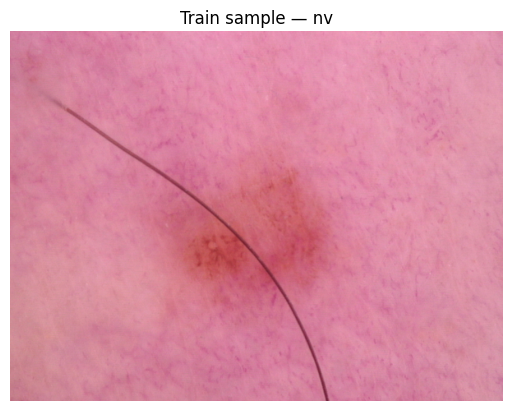

In [29]:
import random

sample = train_df.sample(1).iloc[0]

img = plt.imread(sample['filepath'])
plt.imshow(img)
plt.title(f"Train sample — {sample['dx_name']}")
plt.axis("off")


(-0.5, 599.5, 449.5, -0.5)

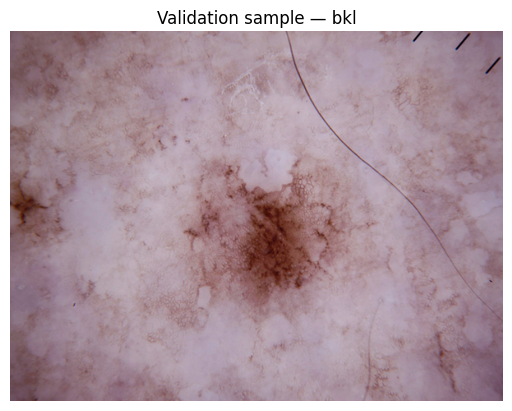

In [32]:
sample = val_df.sample(1).iloc[0]

img = plt.imread(sample['filepath'])
plt.imshow(img)
plt.title(f"Validation sample — {sample['dx_name']}")
plt.axis("off")


In [33]:
train_df.to_csv("dataset/HAM10000/train.csv", index=False)
val_df.to_csv("dataset/HAM10000/val.csv", index=False)

print("Train and validation CSVs saved.")


Train and validation CSVs saved.


In [34]:
train_df = pd.read_csv("dataset/HAM10000/train.csv")
val_df = pd.read_csv("dataset/HAM10000/val.csv")

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))


Train samples: 8012
Val samples: 2003


In [76]:
IMG_SIZE = (380, 380)
BATCH_SIZE = 32
NUM_CLASSES = 7
AUTOTUNE = tf.data.AUTOTUNE


In [77]:
def load_and_decode_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    return img


In [78]:
# resizing the image function
def preprocess_image(img):
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img


In [79]:
def process_path(path, label):
    img = load_and_decode_image(path)
    img = preprocess_image(img)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label


In [80]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df['filepath'].values, train_df['label'].values)
)

train_ds = train_ds.map(
    process_path,
    num_parallel_calls=AUTOTUNE
)


In [82]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df['filepath'].values, val_df['label'].values)
)

val_ds = val_ds.map(
    process_path,
    num_parallel_calls=AUTOTUNE
)


In [83]:
train_ds = train_ds.shuffle(1024)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(AUTOTUNE)


In [84]:
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.cache()
val_ds = val_ds.prefetch(AUTOTUNE)


In [85]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)


Image batch shape: (32, 380, 380, 3)
Label batch shape: (32, 7)


2025-12-19 02:29:42.515410: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


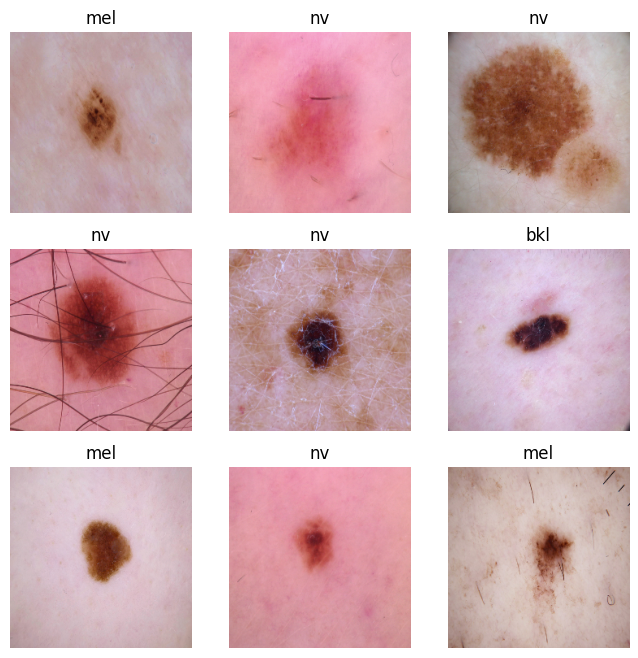

In [44]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    label_idx = tf.argmax(labels[i]).numpy()
    plt.title(inv_label_map[label_idx])
    plt.axis("off")

plt.show()


In [45]:
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())


Train batches: 251
Val batches: 63


In [46]:
INPUT_SHAPE = (224, 224, 3)
LEARNING_RATE = 1e-3
EPOCHS = 10


In [47]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model


In [48]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)


In [49]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)


Base model trainable: False


In [50]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)


In [51]:
model = Model(inputs=base_model.input, outputs=outputs)


In [52]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [53]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,442 (16.08 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="models/baseline_best.keras",
    monitor="val_loss",
    save_best_only=True
)


In [55]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 164s 626ms/step - accuracy: 0.6665 - loss: 1.1874 - val_accuracy: 0.6695 - val_loss: 1.1316
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 583ms/step - accuracy: 0.6694 - loss: 1.1685 - val_accuracy: 0.6695 - val_loss: 1.1335
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 145s 577ms/step - accuracy: 0.6695 - loss: 1.1647 - val_accuracy: 0.6695 - val_loss: 1.1348
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 133s 531ms/step - accuracy: 0.6695 - loss: 1.1597 - val_accuracy: 0.6695 - val_loss: 1.1370


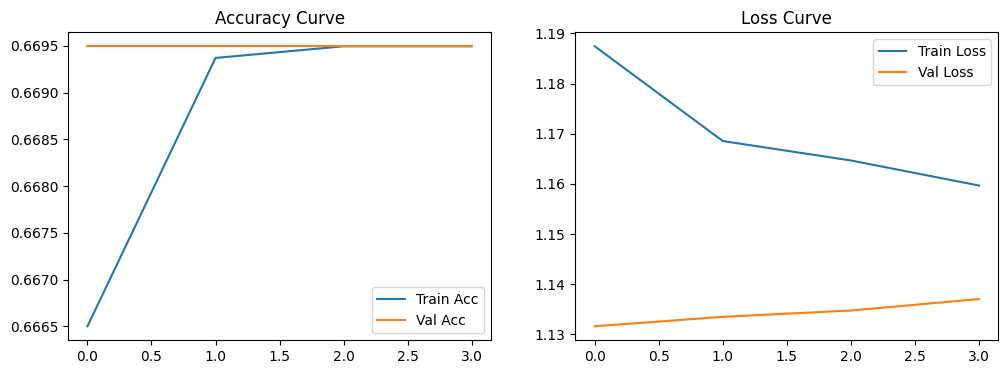

In [56]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()


In [57]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc:.4f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 425ms/step - accuracy: 0.6695 - loss: 1.1316
Validation Accuracy: 0.6695


In [87]:
base_model = tf.keras.applications.EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(380, 380, 3)
)

base_model.trainable = False
print("Base model frozen:", not base_model.trainable)


Base model frozen: True


In [88]:
inputs = tf.keras.Input(shape=(380, 380, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(512, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(7, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 12, 12, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,709,750 (44.67 MB)

 Trainable params: 923,143 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [89]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [90]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_df["label"].values

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(zip(np.unique(labels), class_weights_array))
class_weights


{0: 4.368593238822246,
 1: 2.7848453249913105,
 2: 1.3021290427433772,
 3: 12.440993788819876,
 4: 1.2860353130016051,
 5: 0.21338020666879728,
 6: 10.040100250626567}

In [63]:
print(type(class_weights))
print(class_weights.keys())


<class 'dict'>
dict_keys([0, 1, 2, 3, 4, 5, 6])


In [73]:
import tensorflow as tf
tf.keras.backend.clear_session()
print("TensorFlow session cleared")


TensorFlow session cleared


In [91]:
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)


Epoch 1/8


137/251 ━━━━━━━━━━━━━━━━━━━━ 6:26 3s/step - accuracy: 0.1781 - loss: 3.2159

KeyboardInterrupt: 